In [1]:
import os
import ase
import json
import ase.io
from ase import Atoms
import numpy as np
from pathlib import Path
from glob import glob
from tqdm import tqdm
from itertools import accumulate
from datetime import datetime
from omegaconf import DictConfig, OmegaConf

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from spec2struct.diffusion.diffusion_cfg import CSPDiffusion
from spec2struct.diffusion.property import CSPProperty
from spec2struct.utils.constants import cdvae_train_num_elements_distribution
from spec2struct.dataset.datamodule import CrystalDataModule, worker_init_fn
from spec2struct.dataset.dataset import CrystalDataset

### Instantiate the Forward Model
The forward model predicts node-level DOS from input structures

In [2]:
root_path = Path("outputs/250323_184104_2d_dos_forward")
config_path = root_path / "hparams.yaml"
config = OmegaConf.load(config_path)

# get checkpoint
ckpt_path = glob(str(root_path / "*.ckpt"))[0]

# load model
forward_model = CSPProperty.load_from_checkpoint(ckpt_path, config=config)
forward_model.to('cuda')
print("Forward model loaded.")

Time independence: False
Forward model loaded.


### Instantiate the Data Module
We need to reuse some configs from the saved model folder

In [3]:
root_path = Path("outputs/250705_080702_2d_dos_cfg_ft_truncated")

config_path = root_path / 'hparams.yaml'
config = OmegaConf.load(config_path)
data_module = CrystalDataModule(config, scaler_path=str(root_path))
data_module.setup(stage="test")

/global/cfs/cdirs/m526/shuyi/m526playground/Spec2Struct/spec2struct/dataset/datamodule.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.lattice_scaler = torch.load(

### Create Adhoc Dataset and Dataloader
As an example, we will use the conditionally generated structures from running `generate_CFG_conditional.py`

In [4]:
# path to the folder containing .cif files
data_path = "structures/05072025_194046_2d_dos_ft_perov5supercell_truncated_1000"
save_path = "temp/05072025_194046_2d_dos_ft_perov5supercell_truncated_1000.pt"

adhoc_dataset = CrystalDataset(
    name='adhoc',
    dataset_path=data_path,
    targets_path=None,
    save_path=save_path,
    prop=data_module.config.property,
    niggli=data_module.config.niggli,
    primitive=data_module.config.primitive,
    graph_method=data_module.config.graph_method,
    preprocess_workers=data_module.config.preprocess_workers,
    lattice_scale_method=data_module.config.lattice_scale_method,
    tolerance=data_module.config.tolerance,
)

adhoc_dataset.lattice_scaler = data_module.lattice_scaler
adhoc_dataset.scaler = data_module.scaler

adhoc_loader = DataLoader(
    adhoc_dataset,
    shuffle=False,
    batch_size=len(adhoc_dataset),
    num_workers=1,
    worker_init_fn=worker_init_fn,
)

### Get Ground Truth

In [5]:
# check the IDs of the reconstructed structures
batch = next(iter(adhoc_loader))
print(batch.structure_id)

['cose2_Fe_adatom', 'cose2_Fe_doped', 'cose2_Ni_adatom', 'cose2_Ni_doped', 'cose2_Vacancy-Anion-03', 'cose2_Vacancy-Anion-09A', 'cose2_Vacancy-Anion-09B', 'cose2_Vacancy-Metal', 'cro2_Anti-Anion', 'cro2_Anti-Metal', 'cro2_Cr_adatom', 'cro2_Defect-Free', 'cro2_Int-Anion', 'cro2_Vacancy-Anion-03', 'cro2_Vacancy-Metal', 'crse2_Doped-Li', 'crse2_Ti_adatom', 'crse2_Ti_doped', 'crse2_V_adatom', 'crse2_Vacancy-Anion-03', 'crse2_Vacancy-Metal', 'crte2_Adatom-Li', 'crte2_Anti-Anion', 'crte2_Anti-Metal', 'crte2_Cr_adatom', 'crte2_Defect-Free', 'crte2_Ti_adatom', 'crte2_V_adatom', 'crte2_Vacancy-Anion-03', 'crte2_Vacancy-Metal', 'cus2_Cu_adatom', 'cus2_Defect-Free', 'cus2_Vacancy-Anion-03', 'cus2_Vacancy-Metal', 'cuse2_Cu_adatom', 'cuse2_Defect-Free', 'cuse2_Vacancy-Anion-03', 'cuse2_Vacancy-Metal', 'feo2_Defect-Free', 'feo2_Vacancy-Metal', 'fes2_Co_adatom', 'fes2_Co_doped', 'fes2_Defect-Free', 'fes2_Fe_adatom', 'fes2_Ni_adatom', 'fes2_Ni_doped', 'fes2_Vacancy-Anion-03', 'fes2_Vacancy-Anion-09A',

In [6]:
# since we reconstructed from test set
# we can find the ground truth structures and their DOS's from test.json
f = open("data/2d_dos_truncated/train.json")
raw_data = json.load(f)
f.close()

In [7]:
target_dos_dict = {x['structure_id']: np.array(x['y']) for x in raw_data if x['structure_id'] in batch.structure_id}

### Get Predictions from Reconstructed Structures

In [8]:
forward_model.eval()

pred, _ = forward_model.infer(batch.to('cuda'))

# inverse transform
pred = data_module.scaler.inverse_transform(pred.to('cpu')).numpy()

split_indices = list(accumulate(batch.num_atoms.cpu().numpy()))[:-1]
reconstructed_dos_dict = dict(zip(batch.structure_id, np.split(pred, split_indices)))

In [9]:
for k, v in target_dos_dict.items():
    if v.shape != reconstructed_dos_dict[k].shape:
        print(f"Shape mismatch for {k}: target {v.shape}, reconstructed {reconstructed_dos_dict[k].shape}")

Shape mismatch for crse2_Ti_adatom: target (49, 400), reconstructed (48, 400)
Shape mismatch for cuse2_Cu_adatom: target (49, 400), reconstructed (48, 400)
Shape mismatch for mos2-B_V_adatom: target (49, 400), reconstructed (48, 400)
Shape mismatch for nbs2_Anti-Metal: target (48, 400), reconstructed (47, 400)
Shape mismatch for nbs2_Fe_adatom: target (49, 400), reconstructed (48, 400)
Shape mismatch for wse2_Anti-Anion: target (48, 400), reconstructed (47, 400)


In [10]:
# get MAE
def dicts_mae_per_id(dict_a, dict_b):
    # only use keys present in both dicts and with matching shapes
    per_id = {
        k: float(np.mean(np.abs(dict_a[k] - dict_b[k])))
        for k in dict_a.keys() & dict_b.keys()
        if dict_a[k].shape == dict_b[k].shape
    }
    # global MAE over those entries
    global_mae = float(np.mean(list(per_id.values()))) if per_id else 0.0
    return global_mae, per_id

global_mae, per_id = dicts_mae_per_id(target_dos_dict, reconstructed_dos_dict)
print(f"Global MAE: {global_mae}")

Global MAE: 0.22116787972117588


In [15]:
gt_atoms_dict = {
    x['structure_id']: Atoms(
        numbers=x['atomic_numbers'],
        positions=x['positions'],
        cell=x['cell'],
        pbc=True
    )
    for x in raw_data
}

In [16]:
gen_atoms_dict = {
    Path(p).stem : ase.io.read(p)
    for p in glob(str(Path(data_path) / "*.cif"))
}

In [19]:
min_mae = float('inf')
min_key = None
for k, v in per_id.items():
    gt_atoms = gt_atoms_dict[k]
    gen_atoms = gen_atoms_dict[k]
    gt_comp = sorted(gt_atoms.get_chemical_symbols())
    gen_comp = sorted(gen_atoms.get_chemical_symbols())
    if gt_comp == gen_comp:
        if v < min_mae:
            min_mae = v
            min_key = k

In [20]:
min_key

'nbse2_Anti-Anion'

### Plot

In [12]:
import matplotlib.pyplot as plt

In [13]:
def plot_single(key, predicted, target, n_cols, n_rows):
    """
    Plot each atom’s target vs. generated trace in a grid of subplots.

    Args:
        key (str): Title for the whole figure.
        predicted (np.ndarray): shape (n_atoms, y_dim)
        target    (np.ndarray): shape (n_atoms, y_dim)
        n_cols    (int): number of columns in the subplot grid
        n_rows    (int): number of rows in the subplot grid
    """
    n_atoms = predicted.shape[0]
    total_plots = n_cols * n_rows

    if n_atoms > total_plots:
        raise ValueError(f"Grid too small: need at least {n_atoms} cells but got {total_plots}.")

    # sizing parameters
    aspect_ratio = 1.0            # width / height of each subplot
    subplot_w = 2                 # inches
    subplot_h = subplot_w / aspect_ratio

    fig_w = n_cols * subplot_w
    fig_h = n_rows * subplot_h

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), squeeze=False)
    axes = axs.flatten()

    for idx in range(n_atoms):
        ax = axes[idx]
        ax.plot(target[idx],    label='Target',    linewidth=1.5, alpha=0.75)
        ax.plot(predicted[idx], label='Generated', linewidth=1.5, alpha=0.75)
        ax.set_title(f'Atom {idx}')

    # turn off any unused axes
    for ax in axes[n_atoms:]:
        ax.axis('off')

    fig.suptitle(key, fontsize=14)

    # shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='upper center',
               bbox_to_anchor=(0.5, -0.02),
               ncol=2)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Plotting cose2_Fe_adatom...


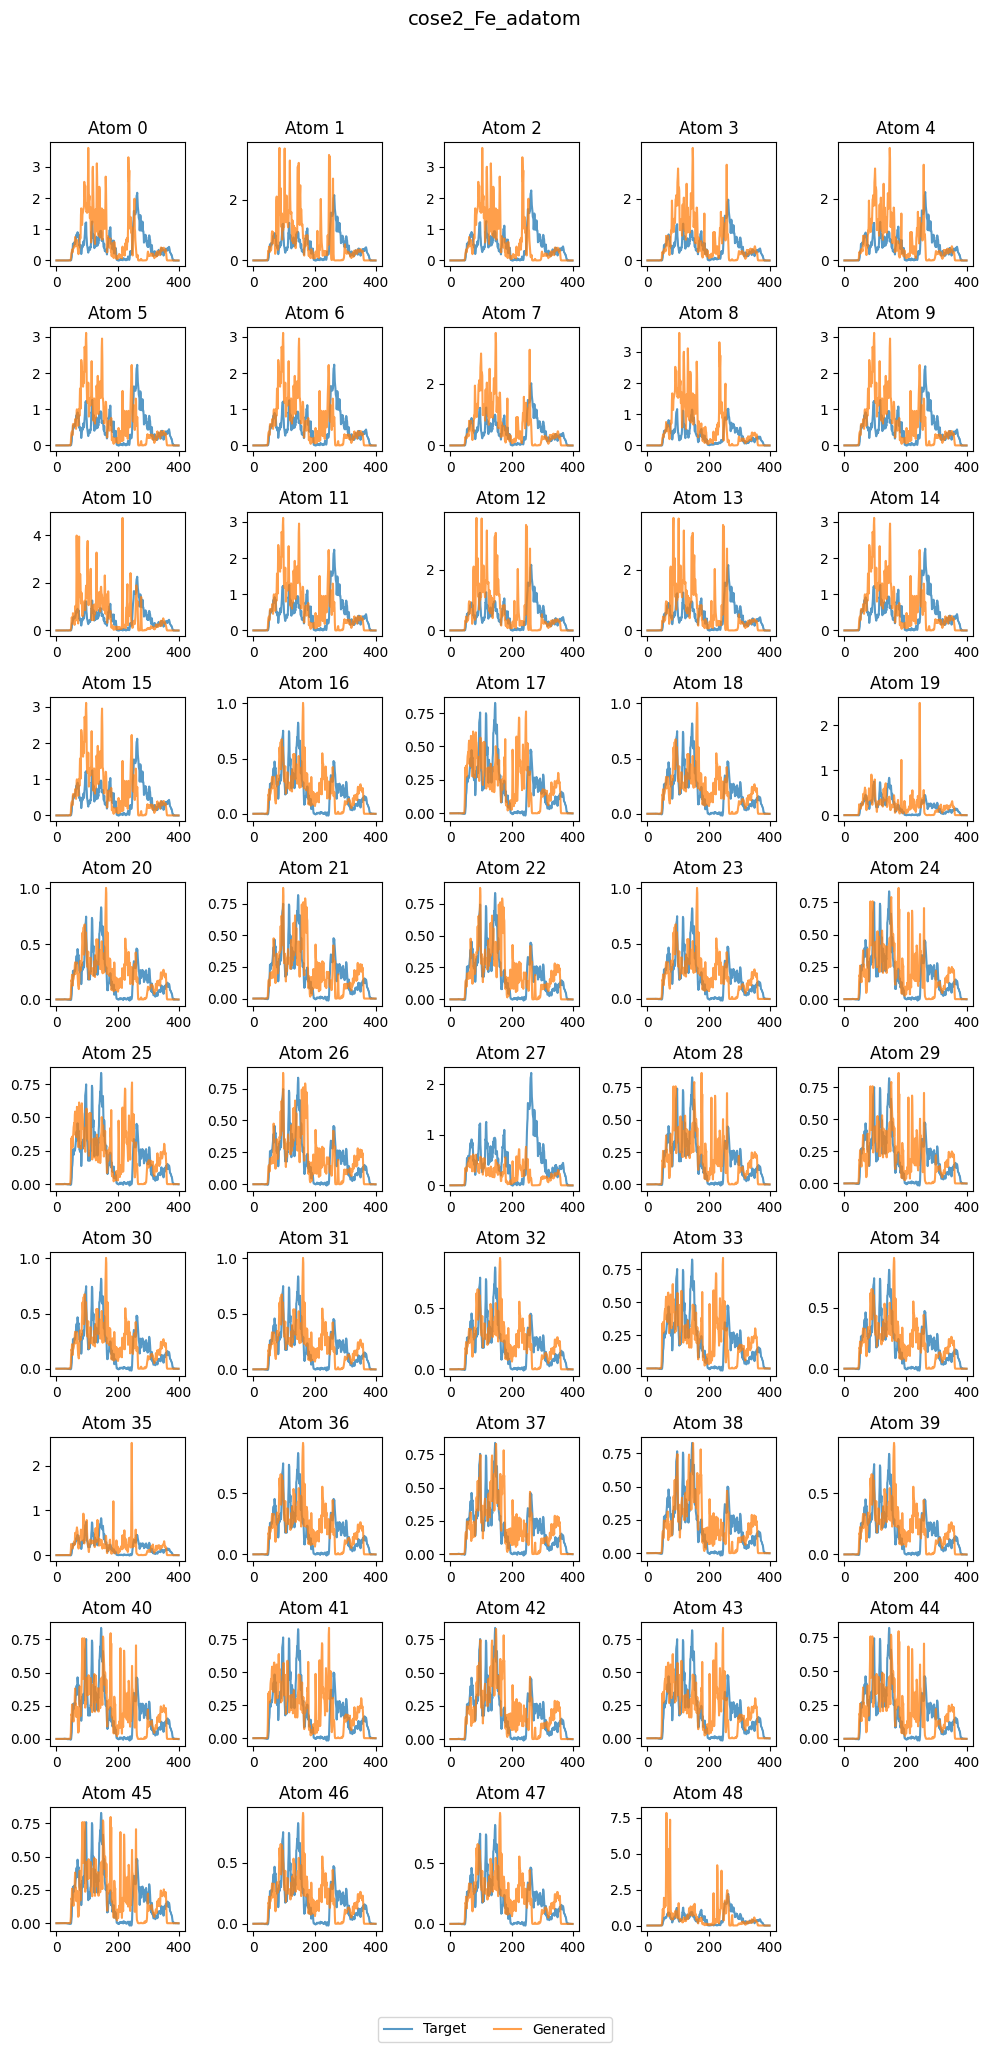

In [14]:
for key in batch.structure_id:
    print(f"Plotting {key}...")
    plot_single(key, target_dos_dict[key], reconstructed_dos_dict[key], n_cols=5, n_rows=10)

    break